# **1. Perkenalan Dataset**

Dataset yang digunakan pada eksperimen ini adalah Breast Cancer Wisconsin (Diagnostic). Dataset ini bersumber dari UCI Machine Learning Repository dan tersedia langsung melalui library scikit-learn, sehingga dapat dimuat ulang secara reproducible tanpa bergantung pada file eksternal.

Dataset berisi 569 sampel hasil pengukuran citra digital dari fine needle aspirate (FNA) massa payudara, dengan 30 fitur numerik (mis. radius, texture, perimeter, area, smoothness) dan 1 kolom target biner:
   - 0 = malignant (ganas)
   - 1 = benign (jinak)

# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka Python yang dibutuhkan untuk loading data, EDA, dan preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')


# **3. Memuat Dataset**

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print('Shape:', df.shape)
df.head()


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini kita melihat struktur data, distribusi kelas, korelasi antar fitur, dan mengecek kualitas data secara umum.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [5]:
print('Total missing value pada seluruh dataset:', df.isnull().sum().sum())
print('Jumlah baris duplikat:', df.duplicated().sum())


Total missing value pada seluruh dataset: 0
Jumlah baris duplikat: 0


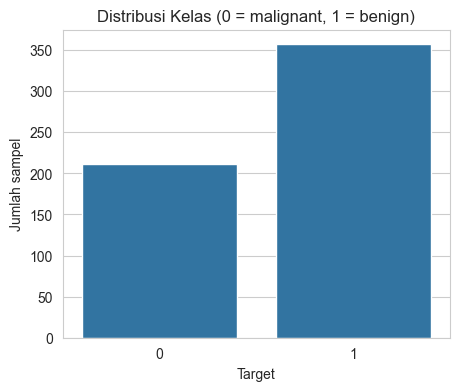

target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title('Distribusi Kelas (0 = malignant, 1 = benign)')
plt.xlabel('Target')
plt.ylabel('Jumlah sampel')
plt.show()

print(df['target'].value_counts(normalize=True))


['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area', 'mean radius', 'mean area', 'mean concavity', 'worst concavity']


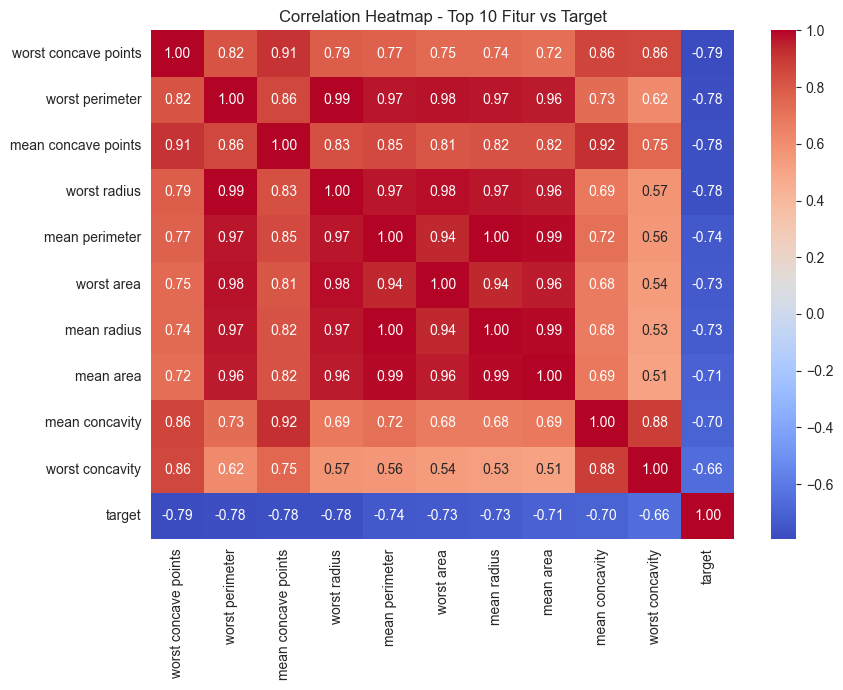

In [7]:
corr = df.corr(numeric_only=True)['target'].abs().sort_values(ascending=False)
top_features = corr.index[1:11]
print(top_features.tolist())

plt.figure(figsize=(9,7))
sns.heatmap(df[top_features.tolist() + ['target']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top 10 Fitur vs Target')
plt.tight_layout()
plt.show()


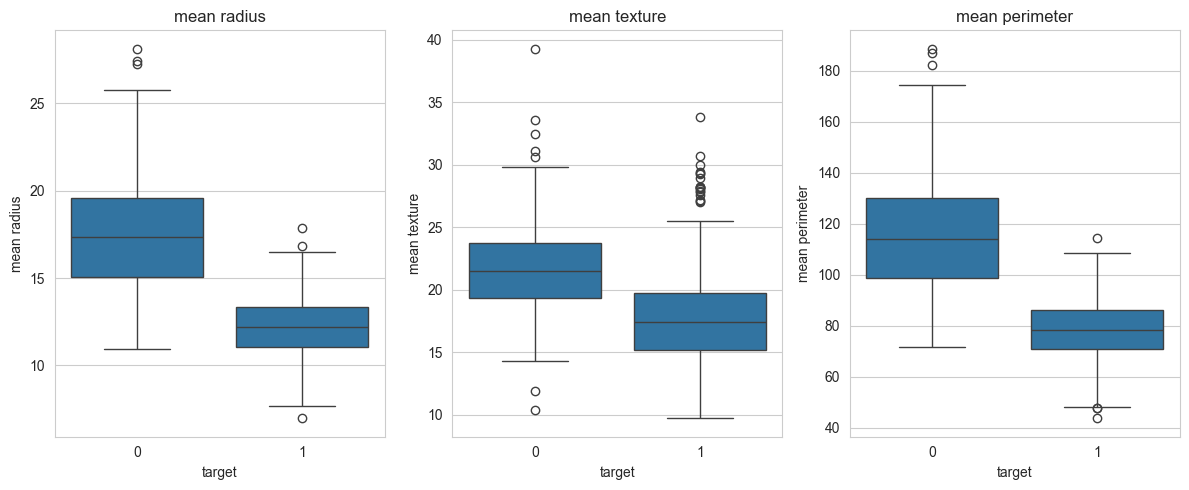

In [8]:
plt.figure(figsize=(12,5))
for i, col in enumerate(['mean radius', 'mean texture', 'mean perimeter'], 1):
    plt.subplot(1,3,i)
    sns.boxplot(x='target', y=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()


**Insight EDA:**
- Tidak ada missing value maupun baris duplikat pada dataset.
- Kelas sedikit imbalance (62.7% benign vs 37.3% malignant), tetapi masih dalam batas wajar untuk klasifikasi biner.
- Fitur mean radius, mean perimeter, mean concave points berkorelasi kuat terhadap target.
- Skala antar fitur berbeda jauh (mean area bisa ratusan, mean smoothness < 1).

# **5. Data Preprocessing**

Berdasarkan insight EDA, tahapan preprocessing yang dilakukan pada dataset ini:
1. Train-test split karena dataset tidak memiliki missing value/duplikat sehingga tahap cleaning tidak diperlukan.
2. Standarisasi fitur menggunakan StandardScaler karena skala antar fitur berbeda jauh.
3. Menyimpan hasil preprocessing.

In [9]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print('Train shape:', X_train_scaled.shape)
print('Test shape :', X_test_scaled.shape)


Train shape: (455, 30)
Test shape : (114, 30)


In [10]:
import os

train_df = X_train_scaled.copy()
train_df['target'] = y_train.values

test_df = X_test_scaled.copy()
test_df['target'] = y_test.values

local_out_dir = 'breast_cancer_preprocessing'
os.makedirs(local_out_dir, exist_ok=True)
train_df.to_csv(os.path.join(local_out_dir, 'train.csv'), index=False)
test_df.to_csv(os.path.join(local_out_dir, 'test.csv'), index=False)

model_out_dir = '../../Membangun_model/breast_cancer_preprocessing'
os.makedirs(model_out_dir, exist_ok=True)
train_df.to_csv(os.path.join(model_out_dir, 'train.csv'), index=False)
test_df.to_csv(os.path.join(model_out_dir, 'test.csv'), index=False)

print('Preprocessed data tersimpan di kedua lokasi.')
train_df.head()


Preprocessed data tersimpan di kedua lokasi.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
546,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,-0.704861,-0.440938,-0.743949,-0.629805,0.000748,-0.991573,-0.693760,-0.983284,-0.591579,-0.428972,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380,1
432,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,0.127567,-0.381383,0.094075,0.317524,0.639656,0.087389,0.708451,1.182150,0.426212,0.074797,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739,0
174,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,-0.254445,1.237130,-0.338634,-0.413827,0.520240,-0.833114,-1.006736,-1.857894,1.356046,-1.006560,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033,1
221,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,-0.531049,-1.262281,-0.411682,-0.436600,-0.393580,-0.129997,-0.219965,-0.527278,-0.269450,-0.316623,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266,1
289,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,-0.498529,1.322961,-0.440597,-0.521457,-0.174225,-0.628196,-0.581187,-0.278344,1.528534,-0.313022,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639,1


In [11]:
from automate_Mayla import preprocess_data

train_df, test_df = preprocess_data(
    raw_path="../breast_cancer_raw/data.csv",
    output_dir="breast_cancer_preprocessing_automate"
)

2026-07-26 12:53:31,695 - INFO - Membaca raw data dari ../breast_cancer_raw/data.csv
2026-07-26 12:53:31,727 - INFO - Melakukan train-test split (test_size=0.20)
2026-07-26 12:53:31,729 - INFO - Melakukan standardisasi fitur dengan StandardScaler
2026-07-26 12:53:31,750 - INFO - Preprocessing selesai. Train: (455, 31) | Test: (114, 31)
2026-07-26 12:53:31,751 - INFO - Data tersimpan di: breast_cancer_preprocessing_automate\train.csv , breast_cancer_preprocessing_automate\test.csv
